# Placeholder for document purpose

In [1]:
# Handling imports 
import gymnasium as gym
import math 
import random
import matplotlib
import matplotlib.pyplot as plt

from collections import namedtuple, deque

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from itertools import count
from IPython import display

#Inline display for the notebook
%matplotlib inline 

# Setting up the GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device : {device}")
if torch.cuda.is_available():
    gpu_id = torch.cuda.current_device()
    
    print(f"GPU : {torch.cuda.get_device_name(gpu_id)}" )
    print(f"GPU capability: {torch.cuda.get_device_capability(gpu_id)}")
    
    gpu_props = torch.cuda.get_device_properties(gpu_id)
    
    print(f"GPU Memory : {gpu_props.total_memory // 1024**3: .2f} GB")
    print(f"Multiprocessors: {gpu_props.multi_processor_count}")
    print(f"Max Threads/MP : {gpu_props.max_threads_per_multi_processor}")

Using Device : cuda
GPU : NVIDIA GeForce RTX 3060
GPU capability: (8, 6)
GPU Memory :  11.00 GB
Multiprocessors: 28
Max Threads/MP : 1536


In [2]:
# Model Setup

class DQN(nn.Module):
    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        
        # Using a simple thtree layer network
        self.layer1 = nn.Linear(n_observations, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, n_actions)
        
    # Called with either one element to determine next action, or a batch during optimization
    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = F.relu(self.layer3(x))
        return x
        

In [3]:
# The replay memory

Transition = namedtuple("Transition", ('state', 'action', 'next_state', 'reward'))

class ReplayMemory(object):
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)
    
    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args)) # why are we using *args here?
    
    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)
    
    def __len__(self):
        return len(self.memory)


In [4]:
# Vizualization helper 

episode_durations = []

def plot_durations(show_result = False):
    plt.figure(1)
    durations_t = torch.tensor(episode_durations, dtype=torch.float)
    if show_result : 
        plt.title("Result")
    else:
        plt.clf()
        plt.title("Training...")
    plt.xlabel("Episode")
    plt.ylabel("Duraton (Score)")
    plt.plot(durations_t.numpy())
    
    # Take 100 episode avaerages and plot them too
    if len(durations_t) >= 100:
        means = durations_t.unfold(0, 100, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(99), means))
        plt.plot(means.numpy())
    
    # update the notebook display
    display.clear_output(wait=True)
    display.display(plt.gcf())

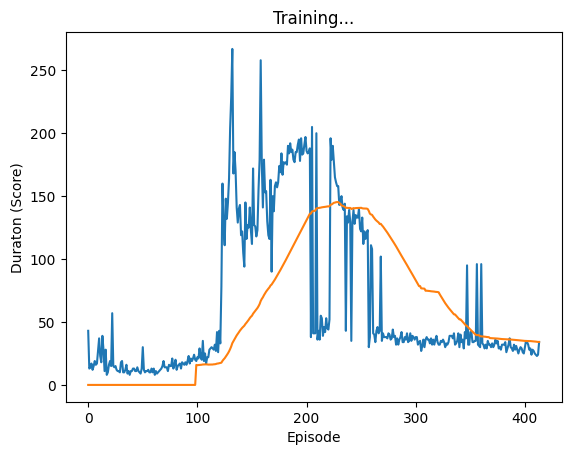

KeyboardInterrupt: 

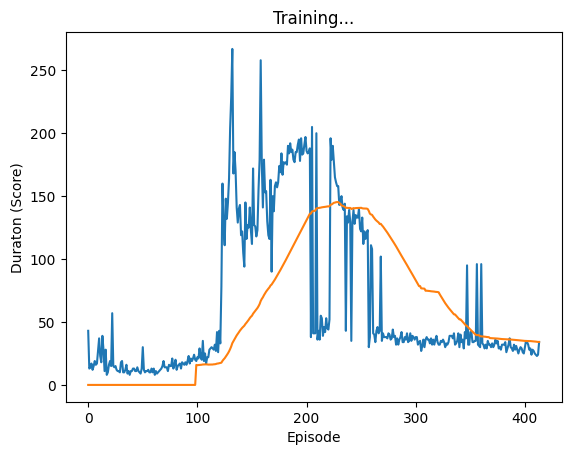

In [5]:
# Training Loop
# --- HYPERPARAMETERS ---
BATCH_SIZE = 128
GAMMA = 0.99
EPS_START = 0.9
EPS_END = 0.05
EPS_DECAY = 1000
TAU = 0.005
LR = 1e-4

# --- SETUP ENVIRONMENT ---
env = gym.make("CartPole-v1", render_mode="human")
n_actions = env.action_space.n
state, info = env.reset()
n_observations = len(state)

policy_net = DQN(n_observations, n_actions).to(device)
target_net = DQN(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(10000)
steps_done = 0

def select_action(state):
    global steps_done
    sample = random.random()
    eps_threshold = EPS_END + (EPS_START - EPS_END) * \
        math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1
    if sample > eps_threshold:
        with torch.no_grad():
            return policy_net(state).max(1).indices.view(1, 1)
    else:
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)

def optimize_model():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)
    batch = Transition(*zip(*transitions))
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    state_action_values = policy_net(state_batch).gather(1, action_batch)
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

# --- MAIN LOOP ---
num_episodes = 500

for i_episode in range(num_episodes):
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    for t in count():
        action = select_action(state)
        observation, reward, terminated, truncated, _ = env.step(action.item())
        reward = torch.tensor([reward], device=device)
        done = terminated or truncated

        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

        memory.push(state, action, next_state, reward)
        state = next_state

        optimize_model()

        target_net_state_dict = target_net.state_dict()
        policy_net_state_dict = policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
        target_net.load_state_dict(target_net_state_dict)

        if done:
            episode_durations.append(t + 1)
            plot_durations() # Update the plot live!
            break

print('Complete')
plot_durations(show_result=True)
plt.ioff()
plt.show()
env.close()

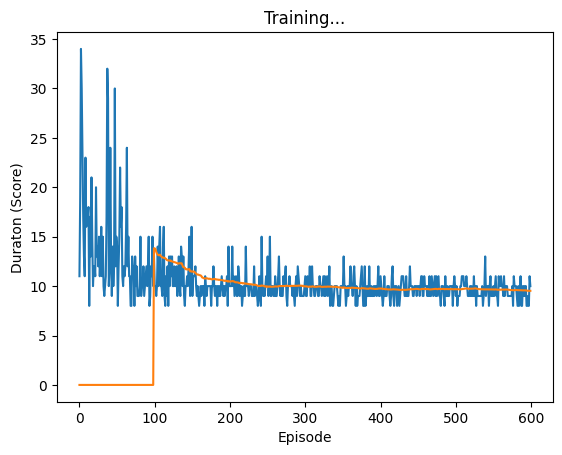

✅ Training Complete!
🎥 Launching Demo...


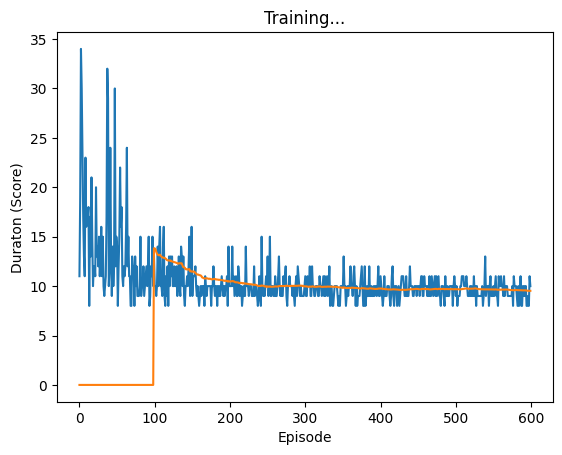

In [6]:
# --- OPTIMIZED TRAINING (NO RENDERING) ---

# 1. Create the environment WITHOUT rendering for speed
env = gym.make("CartPole-v1", render_mode=None)

# ... (Re-initialize networks to reset learning) ...
n_actions = env.action_space.n
state, info = env.reset()
n_observations = len(state)

policy_net = DQN(n_observations, n_actions).to(device)
target_net = DQN(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(10000)
steps_done = 0
episode_durations = []

# Increase episodes because it will be FAST now
num_episodes = 600 

print(f"🚀 Training {num_episodes} episodes on {device} (High Speed)...")

for i_episode in range(num_episodes):
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    for t in count():
        action = select_action(state)
        observation, reward, terminated, truncated, _ = env.step(action.item())
        reward = torch.tensor([reward], device=device)
        done = terminated or truncated

        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

        memory.push(state, action, next_state, reward)
        state = next_state

        optimize_model()

        target_net_state_dict = target_net.state_dict()
        policy_net_state_dict = policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
        target_net.load_state_dict(target_net_state_dict)

        if done:
            episode_durations.append(t + 1)
            plot_durations() # Still updates the graph
            break

print('✅ Training Complete!')
env.close()

# --- DEMO PHASE (WATCH IT PLAY) ---
print("🎥 Launching Demo...")
env_demo = gym.make("CartPole-v1", render_mode="human")
state, info = env_demo.reset()
state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

while True:
    # Select action with the trained policy (No randomness)
    with torch.no_grad():
        action = policy_net(state).max(1).indices.view(1, 1)
    
    observation, reward, terminated, truncated, _ = env_demo.step(action.item())
    
    if terminated or truncated:
        break
        
    state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

env_demo.close()

In [7]:
import time

# --- WATCH YOUR TRAINED AGENT (5 GAMES) ---
print("🎥 Launching Demo... Watch the popup window!")

# Create the environment with visualization
env_demo = gym.make("CartPole-v1", render_mode="human")

for i in range(5): # Play 5 games
    state, info = env_demo.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    total_reward = 0
    
    for t in count():
        # Select the best action (No random exploration)
        with torch.no_grad():
            action = policy_net(state).max(1).indices.view(1, 1)
        
        observation, reward, terminated, truncated, _ = env_demo.step(action.item())
        total_reward += reward
        
        if terminated or truncated:
            print(f"Game {i+1} Score: {total_reward}")
            time.sleep(1) # Pause for 1 second between games
            break
            
        state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

print("✅ Demo Finished. Closing window.")
env_demo.close()

🎥 Launching Demo... Watch the popup window!
Game 1 Score: 9.0
Game 2 Score: 9.0
Game 3 Score: 8.0
Game 4 Score: 9.0
Game 5 Score: 9.0
✅ Demo Finished. Closing window.
